<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%202/Multilayer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikeras

In [ ]:
!pip install scikit-learn==1.5.2

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
import time

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

In [ ]:
(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

print("X train shape: ",X_train.shape)
print("y train shape: ",y_train.shape)
print("X test shape: ",X_test.shape)
print("y test shape: ",y_test.shape)

X train shape:  (60000, 28, 28)
y train shape:  (60000,)
X test shape:  (10000, 28, 28)
y test shape:  (10000,)


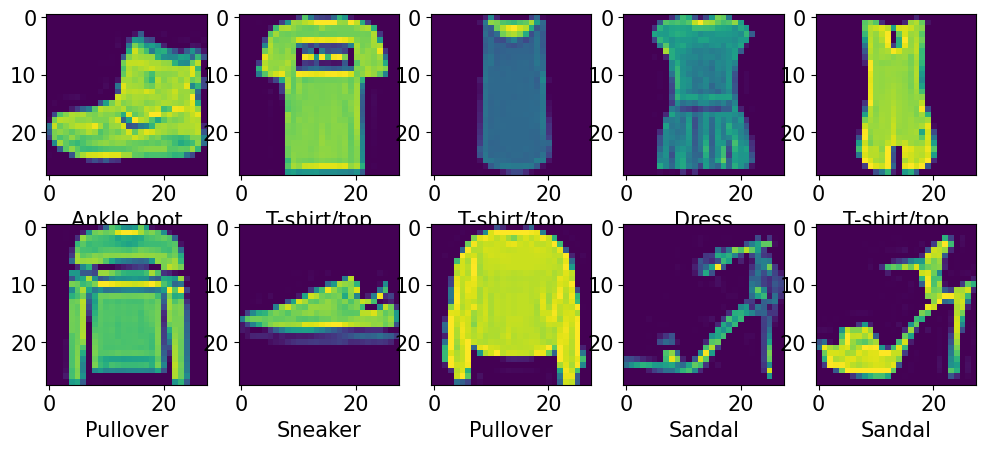

In [ ]:
classes=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.xlabel(classes[y_train[i]])

plt.savefig("sample_images.eps",dpi=600)
plt.show()


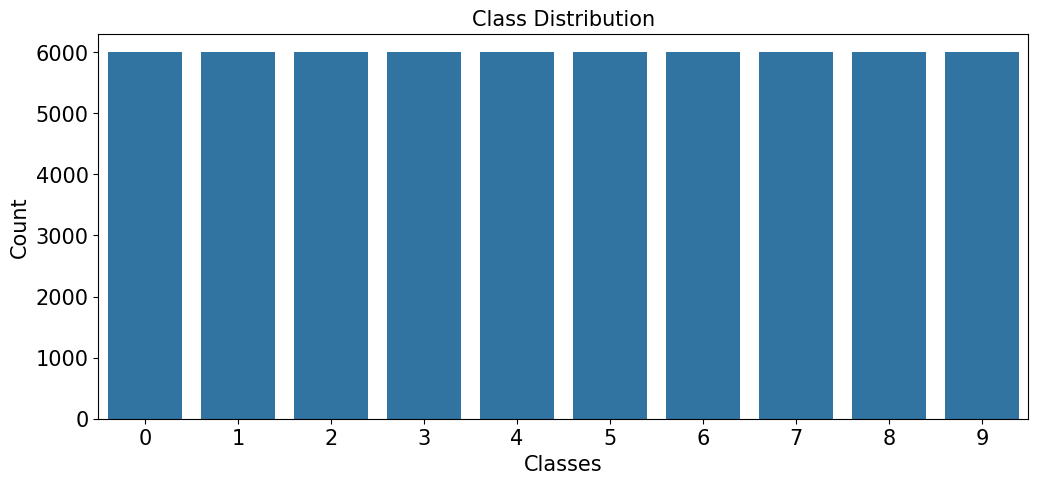

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x=y_train)
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.savefig("class_distribution.eps",dpi=600)
plt.show()

In [ ]:
X_train_f=X_train.reshape(-1,784)
X_test_f=X_test.reshape(-1,784)

print("X train shape:",X_train_f.shape)
print("X test shape:",X_test_f.shape)

X train shape: (60000, 784)
X test shape: (10000, 784)


In [ ]:
X_train_f=X_train_f/255
X_test_f=X_test_f/255

y_train_v=to_categorical(y_train)
y_test_v=to_categorical(y_test)

In [ ]:
print("Before Preprocessing:")
print("X train shape: ",X_train.shape)
print("X test shape: ",X_test.shape)

print("After preprocessing:")
print("X train shape: ",X_train_f.shape)
print("X test shape: ",X_test_f.shape)
print("Y train shape: ",y_train_v.shape)
print("Y test shape: ",y_test_v.shape)

Before Preprocessing:
X train shape:  (60000, 28, 28)
X test shape:  (10000, 28, 28)
After preprocessing:
X train shape:  (60000, 784)
X test shape:  (10000, 784)
Y train shape:  (60000, 10)
Y test shape:  (10000, 10)


In [ ]:
baseline=Sequential()

baseline.add(Dense(128,input_shape=(784,),activation='relu'))
baseline.add(Dense(64,activation='relu'))
baseline.add(Dense(10,activation='softmax'))

baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_132"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_406 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_407 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_408 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
start=time.time()
hist=baseline.fit(X_train_f,y_train_v,validation_split=0.2,epochs=20,batch_size=32,verbose=1)
baseline_time=time.time()-start
print("Training Time: ",baseline_time)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8165 - loss: 0.5159 - val_accuracy: 0.8375 - val_loss: 0.4506
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8609 - loss: 0.3820 - val_accuracy: 0.8639 - val_loss: 0.3763
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8733 - loss: 0.3432 - val_accuracy: 0.8639 - val_loss: 0.3689
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8816 - loss: 0.3184 - val_accuracy: 0.8796 - val_loss: 0.3330
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8906 - loss: 0.2961 - val_accuracy: 0.8792 - val_loss: 0.3383
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8947 - loss: 0.2817 - val_accuracy: 0.8729 - val_loss: 0.3588
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8990 - loss: 0.2714 - val_accuracy: 0.8748 - val_loss: 0.3370
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9026 - loss: 0.2592 - 

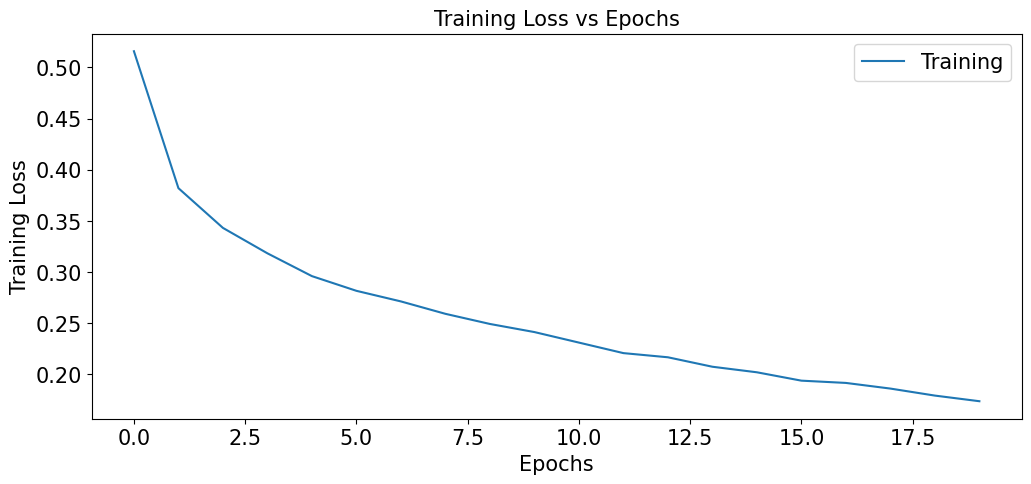

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hist.history['loss'],label='Training')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("Training Loss vs Epochs")
plt.legend()
plt.savefig("training_loss.eps",dpi=600)
plt.show()

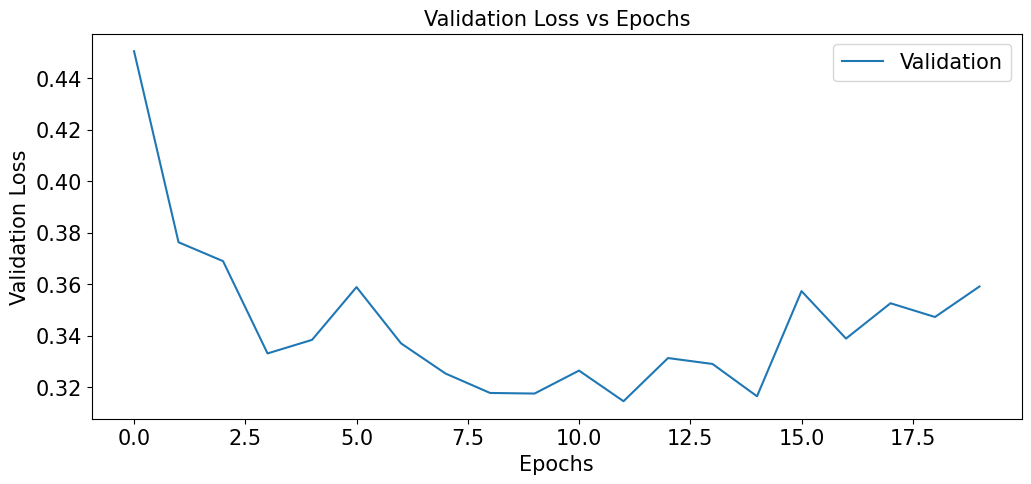

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hist.history['val_loss'],label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title("Validation Loss vs Epochs")
plt.legend()
plt.savefig("validation_loss.eps",dpi=600)
plt.show()

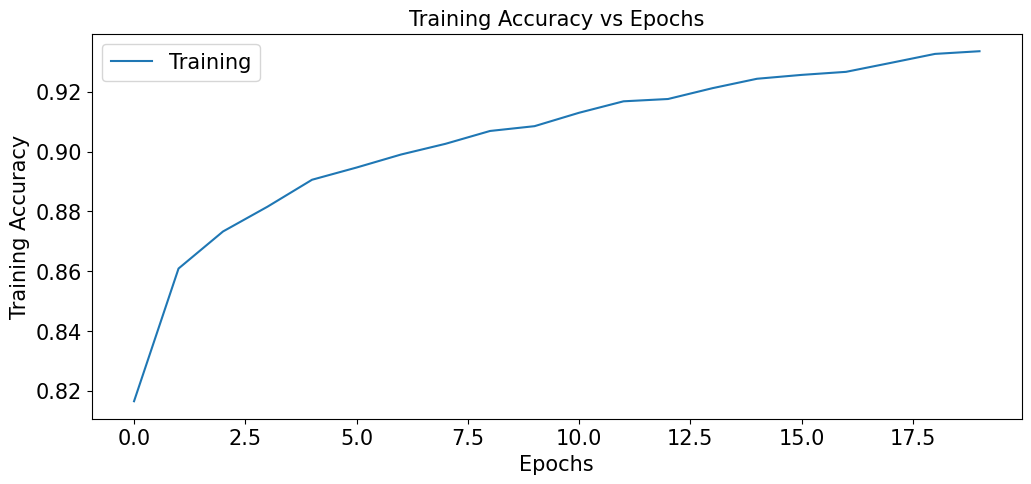

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hist.history['accuracy'],label='Training')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.savefig("training_accuracy.eps",dpi=600)
plt.show()

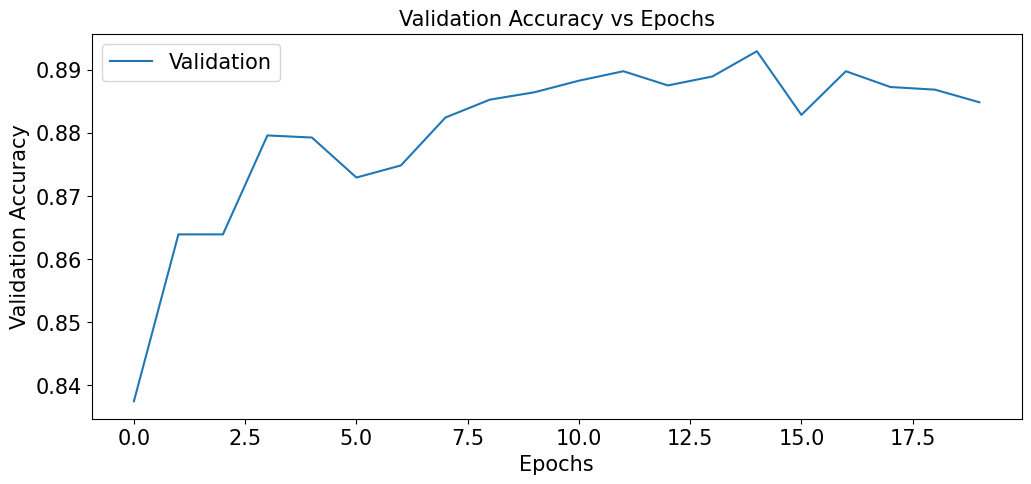

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(hist.history['val_accuracy'],label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title("Validation Accuracy vs Epochs")
plt.legend()
plt.savefig("validation_accuracy.eps",dpi=600)
plt.show()

In [ ]:
pred=baseline.predict(X_test_f)

pred_class=np.argmax(pred,axis=1)

acc=accuracy_score(y_test,pred_class)
prec=precision_score(y_test,pred_class,average="weighted")
rec=recall_score(y_test,pred_class,average="weighted")
f1=f1_score(y_test,pred_class,average="weighted")

print(f"""
Accuracy: {acc}
Precision: {prec}
Recall: {rec}
F1 Score: {f1}
""")




313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Accuracy: 0.8785
Precision: 0.883098811305075
Recall: 0.8785
F1 Score: 0.8798894097187391



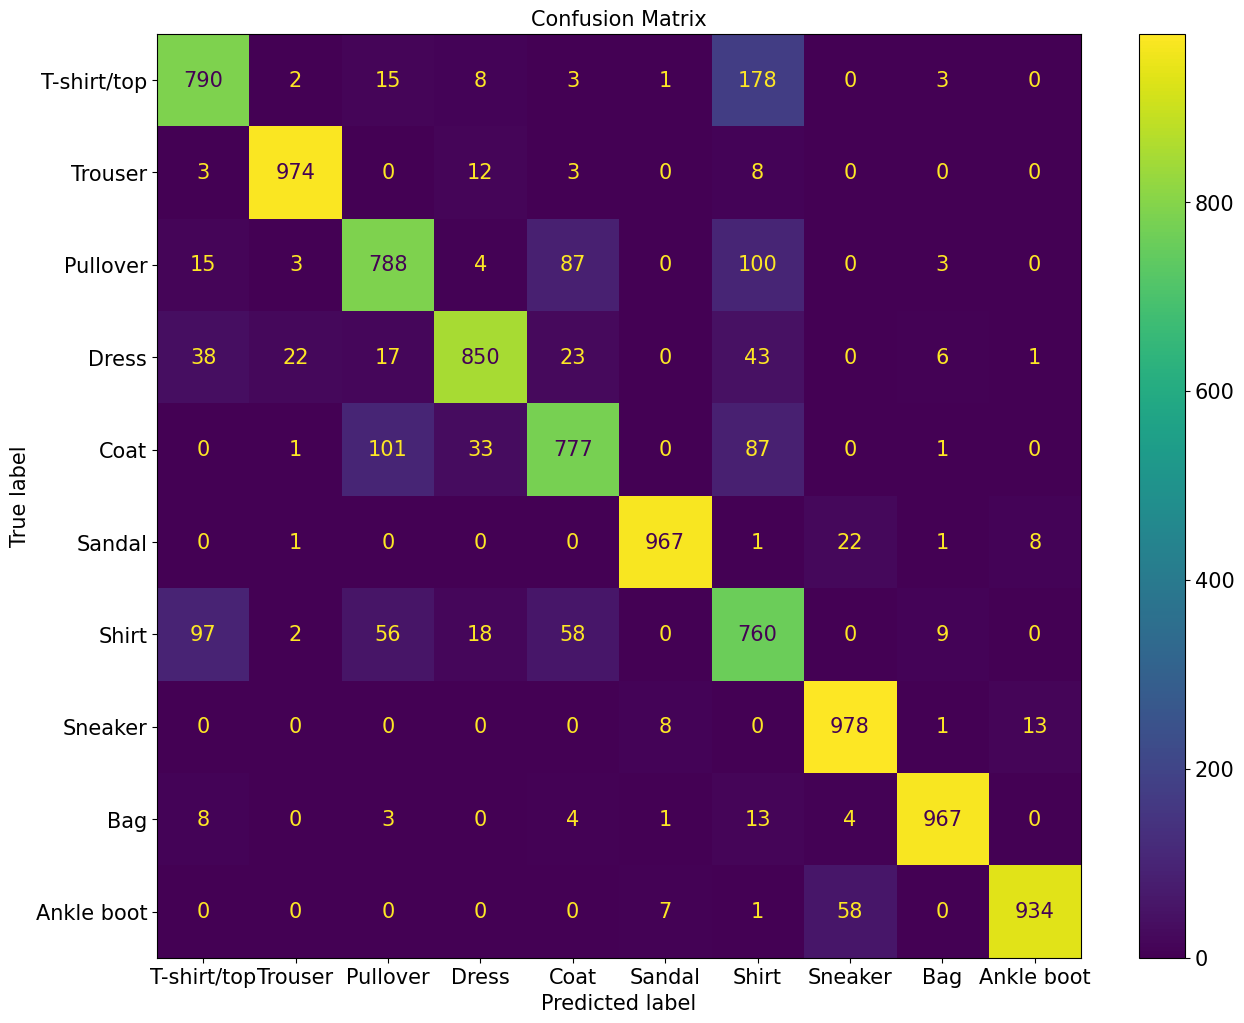

In [ ]:
from matplotlib import axes
cm=confusion_matrix(y_test,pred_class)
fig,ax=plt.subplots(figsize=(15,12))
ConfusionMatrixDisplay(cm,display_labels=classes).plot(ax=ax)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.eps",dpi=600)
plt.show()

In [ ]:
print(classification_report(y_test,pred_class,target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.79      0.81      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.80      0.79      0.80      1000
       Dress       0.92      0.85      0.88      1000
        Coat       0.81      0.78      0.79      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.64      0.76      0.69      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.98      0.93      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
def build_model(optimizer='adam',hidden_layers=2,neurons=128,learning_rate=0.001,activation='relu'):
  model=Sequential()
  model.add(Input(shape=(784,)))
  model.add(Dense(neurons,activation=activation))

  for i in range(hidden_layers-1):
    model.add(Dense(neurons,activation=activation))
  model.add(Dense(10,activation='softmax'))

  if optimizer=='adam':
    opt=Adam(learning_rate=learning_rate)
  elif optimizer=='sgd':
    opt=SGD(learning_rate=learning_rate)
  else:
    opt=RMSprop(learning_rate=learning_rate)

  model.compile(optimizer=opt,loss='categorical_crossentropy',metrics=['accuracy'])

  return model

In [ ]:
cf=KerasClassifier(model=build_model,verbose=0)

In [ ]:
parameters={
    "model__optimizer":['adam','sgd','rmsprop'],
    "model__hidden_layers":[1,2,3],
    "model__neurons":[32,64,128,256],
    "model__learning_rate":[0.001,0.01,0.1],
    "model__activation":['relu','tanh','sigmoid'],
    "batch_size":[16,32,64,128],
    "epochs":[10,20,30]
}


In [ ]:
search=RandomizedSearchCV(cf,parameters,cv=5,n_iter=10,verbose=2,random_state=42)

In [ ]:
start=time.time()
search.fit(X_train_f,y_train_v)
search_time=time.time()-start
print("Training Time: ",search_time)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=128, epochs=10, model__activation=sigmoid, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=128, model__optimizer=adam; total time=  25.2s
[CV] END batch_size=128, epochs=10, model__activation=sigmoid, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=128, model__optimizer=adam; total time=  25.5s
[CV] END batch_size=128, epochs=10, model__activation=sigmoid, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=128, model__optimizer=adam; total time=  24.4s
[CV] END batch_size=128, epochs=10, model__activation=sigmoid, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=128, model__optimizer=adam; total time=  24.5s
[CV] END batch_size=128, epochs=10, model__activation=sigmoid, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=128, model__optimizer=adam; total time=  24.3s
[CV] END batch_size=128, epochs=20, model__activation=

In [ ]:
print("Best Parameters\n")
print(search.best_params_)
print("\nBest CV Accuracy:",search.best_score_)

Best Parameters

{'model__optimizer': 'sgd', 'model__neurons': 64, 'model__learning_rate': 0.1, 'model__hidden_layers': 3, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 128}

Best CV Accuracy: 0.8882


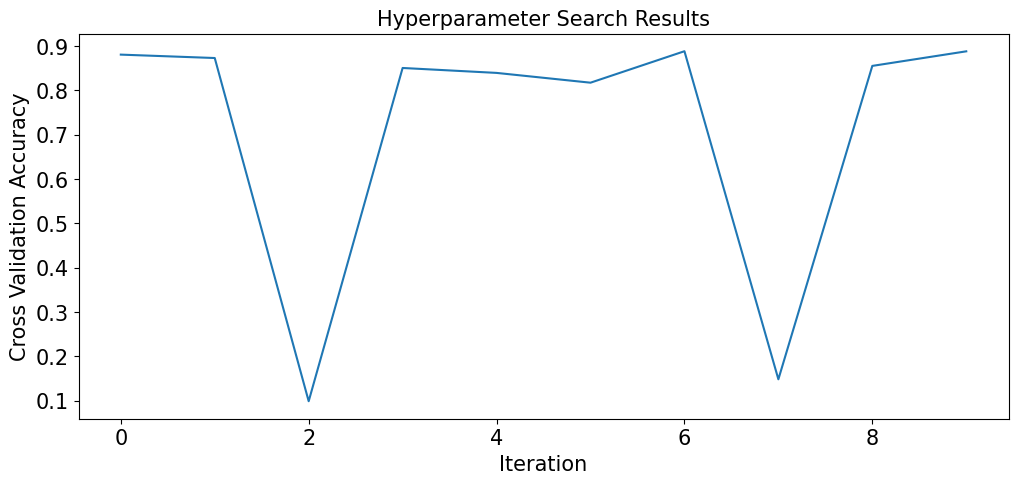

In [ ]:
res=pd.DataFrame(search.cv_results_)
plt.figure(figsize=(12,5))
plt.plot(res['mean_test_score'])
plt.xlabel("Iteration")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.savefig("hyperparameter_search.eps",dpi=600)
plt.show()

In [ ]:
best_model=search.best_estimator_

In [ ]:
best_acc=accuracy_score(y_test,best_pred)
best_prec=precision_score(y_test,best_pred,average="weighted")
best_rec=recall_score(y_test,best_pred,average="weighted")
best_f1=f1_score(y_test,best_pred,average="weighted")

print("Accuracy :",best_acc)
print("Precision :",best_prec)
print("Recall :",best_rec)
print("F1 Score :",best_f1)

Accuracy : 0.8754
Precision : 0.8794349047488306
Recall : 0.8754
F1 Score : 0.8765306254101897


In [ ]:
print(classification_report(y_test,best_pred,target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.77      0.82      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.77      0.81      0.79      1000
       Dress       0.90      0.87      0.88      1000
        Coat       0.81      0.76      0.79      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.64      0.75      0.69      1000
     Sneaker       0.92      0.95      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



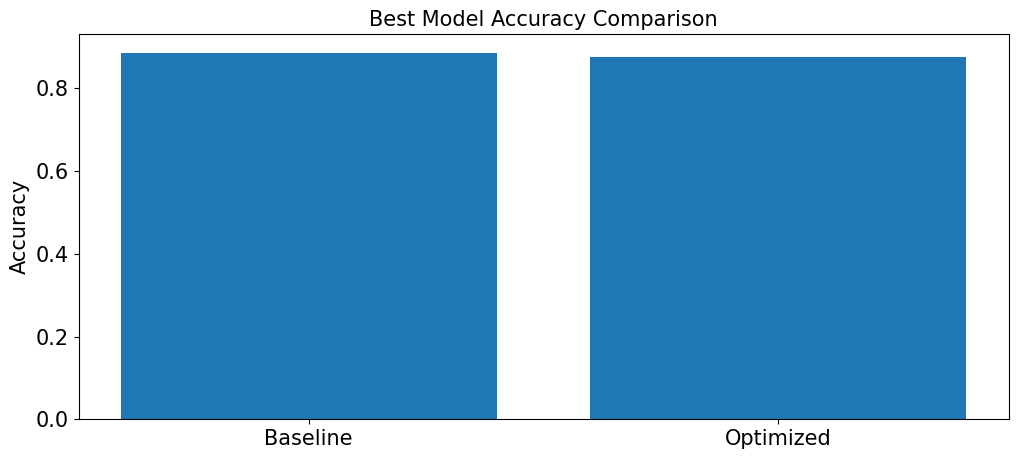

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(["Baseline","Optimized"],[acc,best_acc])
plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")
plt.savefig("accuracy_comparison.eps",dpi=600)
plt.show()